# Exploratory Data Analysis (EDA)
## Prédiction de l'issue d'un round CS2 à partir de l'état freeze-time

## 0. Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import GroupShuffleSplit

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
)

try:
    mpl.style.use("seaborn-v0_8")
except OSError:
    mpl.style.use("seaborn")

mpl.rcParams["image.cmap"] = "plasma"

nice_hist = {
    "bins": "auto",
    "density": True,
    "edgecolor": "white",
}


In [2]:
df_pistol      = pd.read_csv("../data/processed/df_pistol.csv")
df_post_pistol = pd.read_csv("../data/processed/df_post_pistol.csv")
df_normal      = pd.read_csv("../data/processed/df_normal.csv")

df_global = pd.concat([df_pistol,
                       df_post_pistol,
                       df_normal])


In [3]:
dfs = [df_pistol, df_post_pistol, df_normal]
linestyles = [':', '--', '-']

round_types = ['Pistol', 'Post-pistol', 'Normal']

t_color  = "#E8A020" 
ct_color = "#1E3A6E" 

ct_shades = ['#8AAFD4', '#4A6FA5', '#1E3A6E']
t_shades  = ['#F7D99F', '#F0BC60', '#E8A020']


In [4]:
def create_delta(df, pairs, extra_cols):
    df_model = pd.DataFrame()
    for ct_col, t_col, delta_name in pairs:
        if ct_col in df.columns and t_col in df.columns:
            df_model[delta_name] = df[ct_col] - df[t_col]
    for col in extra_cols:
        if col in df.columns:
            df_model[col] = df[col]
    return df_model


In [5]:
def plot_correlation_circle(initial_variables, new_variables, feature_names,
                             axes_pair=(0, 1), savepath=None):
    a, b = axes_pair
    plt.figure(figsize=(8, 8))
    circle = plt.Circle((0, 0), 1, color='gray', fill=False)
    plt.gca().add_artist(circle)
    for i in range(initial_variables.shape[1]):
        x = np.corrcoef(new_variables[:, a], initial_variables[:, i])[0, 1]
        y = np.corrcoef(new_variables[:, b], initial_variables[:, i])[0, 1]
        plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.001,
                  fc='red', ec='red')
        plt.text(x*1.1, y*1.1, feature_names[i], color='black',
                 ha='center', va='center')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.xlabel(f'PC{a+1}'); plt.ylabel(f'PC{b+1}')
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.title(f'Correlation circle — PC{a+1}/PC{b+1}')
    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


In [6]:
def plot_correl(df_delta, ax, title):
    correls = (
        df_delta.drop(columns=['map_name'], errors='ignore')
                .corr()['round_winner']
                .drop('round_winner')
                .sort_values()
    )
    colors = [ct_color if v >= 0 else t_color for v in correls]
    ax.barh(range(len(correls)), correls.values, color=colors)
    ax.set_yticks(range(len(correls)))
    ax.set_yticklabels(correls.index, fontsize=8)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Pearson correlation')


In [7]:
def bar_color(v):
    """Bleu CT si winrate > 50%, jaune T si < 50%, gris si exactement 50%."""
    if round(v * 100) == 50:
        return "#888888"
    return ct_color if v > 0.5 else t_color


In [8]:
def qcut_winrate(df, col, q=5, target='round_winner'):
    tmp = df[[col, target]].dropna().copy()
    tmp['bin'] = pd.qcut(tmp[col], q=q, duplicates='drop')
    return (tmp
            .groupby('bin', observed=True)
            .agg(wr=(target, 'mean'),
               n=(target, 'size'))
            .reset_index()) 


## 1. Dataset overview

### 1.1 Maps and teams

In [9]:
maps_name = df_normal['map_name'].unique()

teams_name = df_normal['ct_team_name'].unique()

print("Maps :", len(maps_name))
print(", ".join(sorted(maps_name)))

print()

print("Teams :", len(teams_name))
print(", ".join(sorted(teams_name)))


Maps : 8
de_ancient, de_anubis, de_dust2, de_inferno, de_mirage, de_nuke, de_overpass, de_train

Teams : 48
3DMAX, Astralis, Aurora, B8, BC.Game, BIG, BetBoom, Betclic, Complexity, ECSTATIC, Eternal Fire, FURIA, FUT, FaZe, Falcons, FlyQuest, G2, GamerLegion, Gentle Mates, HEROIC, HOTU, Imperial, Imperial Valkyries, Inner Circle, Legacy, Liquid, Lynn Vision, M80, MIBR, MOUZ, NRG, Natus Vincere, Nemiga, Ninjas in Pyjamas, ODDIK, PARIVISION, Passion UA, Rare Atom, SAW, Spirit, TYLOO, The Huns, The MongolZ, Virtus.pro, Vitality, Wildcard, fnatic, paiN


### 1.2 Volume: rounds per type

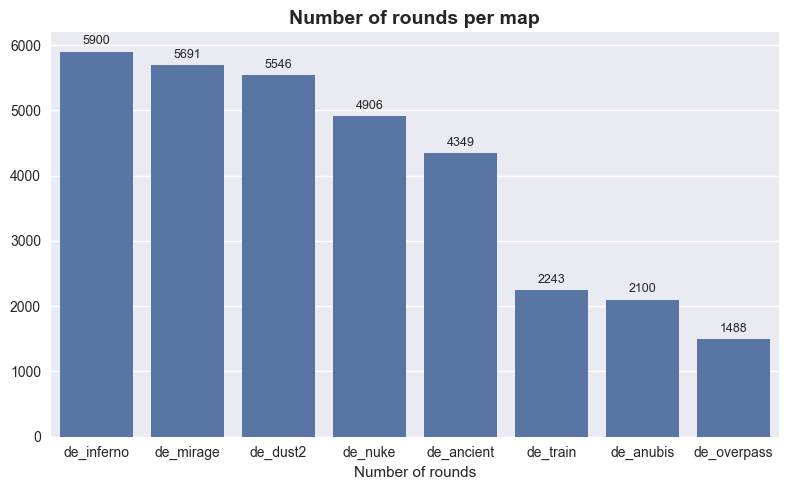

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=df_global['map_name'].value_counts(),
            errorbar=None,
            ax=ax)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

ax.set_title('Number of rounds per map', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of rounds', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
fig.savefig('../report/figures/dataset_rounds_per_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.3 Available features

In [11]:
for df, round_type in zip(dfs, round_types):
    print(f"df_{round_type}: {df.shape}")


df_Pistol: (2945, 70)
df_Post-pistol: (2956, 103)
df_Normal: (26322, 104)


In [12]:
for df, round_type in zip(dfs, round_types):
    print(f" {round_type} features: {df.columns}")


 Pistol features: Index(['ct_team_name', 't_team_name', 'ct_armor_count', 't_armor_count',
       'ct_helmet_count', 't_helmet_count', 'ct_defuser_count',
       'ct_smoke_count', 't_smoke_count', 'ct_molo_count', 't_molo_count',
       'ct_flash_count', 't_flash_count', 'ct_he_count', 't_he_count',
       'ct_utility_value', 't_utility_value', 'ct_equipment_value',
       't_equipment_value', 'round_number', 'ct_score', 't_score', 'map_name',
       'round_winner', 'tournament', 'match_date', 'previous_bomb_planted',
       'ct_loss_count', 't_loss_count', 'ct_loss_bonus', 't_loss_bonus',
       'ct_cash_next_if_loss', 't_cash_next_if_loss', 'round_type',
       'ct_team_global_30d_rating', 'ct_team_global_30d_fa',
       'ct_team_global_30d_pistol_win_pct', 'ct_team_map_30d_rating',
       'ct_team_map_30d_fa', 'ct_team_map_30d_pistol_win_pct',
       't_team_global_30d_rating', 't_team_global_30d_fa',
       't_team_global_30d_pistol_win_pct', 't_team_map_30d_rating',
       't_team

### 1.4 Pearson correlations with round_winner


In [13]:
extra_pistol = ['round_number', 'score_diff', 'map_name', 'round_winner', 'ct_defuser_count']

extra_post_pistol = ['round_number', 'map_name',
                     'ct_rounds_won_streak', 't_rounds_won_streak',
                     'round_winner']

extra_normal = ['round_number', 'map_name',
                'ct_rounds_won_streak', 't_rounds_won_streak',
                'ct_ak_count', 'round_winner']

grenade_pairs = [
    ('ct_smoke_count',  't_smoke_count',  'delta_smoke_count'),
    ('ct_flash_count',  't_flash_count',  'delta_flash_count'),
    ('ct_molo_count',   't_molo_count',   'delta_molo_count'),
    ('ct_he_count',     't_he_count',     'delta_he_count'),
]

pairs_pistol = [
    ('ct_equipment_value',                   't_equipment_value',                   'delta_equipment_value'),
    ('ct_utility_value',                     't_utility_value',                     'delta_utility_value'),
    ('ct_armor_count',                       't_armor_count',                       'delta_armor_count'),
    ('ct_score',                             't_score',                             'score_diff'),
] + grenade_pairs + [
    ('ct_team_global_30d_rating',            't_team_global_30d_rating',            'delta_global_30d_rating'),
    ('ct_team_global_90d_rating',            't_team_global_90d_rating',            'delta_global_90d_rating'),
    ('ct_team_global_6months_rating',        't_team_global_6months_rating',        'delta_global_6months_rating'),
    ('ct_team_map_30d_rating',               't_team_map_30d_rating',               'delta_map_30d_rating'),
    ('ct_team_map_90d_rating',               't_team_map_90d_rating',               'delta_map_90d_rating'),
    ('ct_team_map_6months_rating',           't_team_map_6months_rating',           'delta_map_6months_rating'),
    ('ct_team_global_30d_pistol_win_pct',    't_team_global_30d_pistol_win_pct',    'delta_global_30d_pistol_win_pct'),
    ('ct_team_global_90d_pistol_win_pct',    't_team_global_90d_pistol_win_pct',    'delta_global_90d_pistol_win_pct'),
    ('ct_team_global_6months_pistol_win_pct','t_team_global_6months_pistol_win_pct','delta_global_6months_pistol_win_pct'),
    ('ct_team_map_30d_pistol_win_pct',       't_team_map_30d_pistol_win_pct',       'delta_map_30d_pistol_win_pct'),
    ('ct_team_map_90d_pistol_win_pct',       't_team_map_90d_pistol_win_pct',       'delta_map_90d_pistol_win_pct'),
    ('ct_team_map_6months_pistol_win_pct',   't_team_map_6months_pistol_win_pct',   'delta_map_6months_pistol_win_pct'),
    ('ct_team_global_30d_fa',                't_team_global_30d_fa',                'delta_global_30d_fa'),
    ('ct_team_global_90d_fa',                't_team_global_90d_fa',                'delta_global_90d_fa'),
    ('ct_team_global_6months_fa',            't_team_global_6months_fa',            'delta_global_6months_fa'),
    ('ct_team_map_30d_fa',                   't_team_map_30d_fa',                   'delta_map_30d_fa'),
    ('ct_team_map_90d_fa',                   't_team_map_90d_fa',                   'delta_map_90d_fa'),
    ('ct_team_map_6months_fa',               't_team_map_6months_fa',               'delta_map_6months_fa'),
]

pairs_post_pistol = [
    ('ct_equipment_value',                   't_equipment_value',                   'delta_equipment_value'),
    ('ct_utility_value',                     't_utility_value',                     'delta_utility_value'),
    ('ct_rifle_count',                       't_rifle_count',                       'delta_rifle_count'),
    ('ct_awp_count',                         't_awp_count',                         'delta_awp_count'),
    ('ct_money_total',                       't_money_total',                       'delta_money_total'),
    ('ct_armor_count',                       't_armor_count',                       'delta_armor_count'),
    ('ct_helmet_count',                      't_helmet_count',                      'delta_helmet_count'),
    ('ct_survivors_previous',                't_survivors_previous',                'delta_survivors_previous'),
    ('ct_equipment_saved_value',             't_equipment_saved_value',             'delta_equipment_saved_value'),
    ('ct_rounds_won_streak',                 't_rounds_won_streak',                 'delta_rounds_won_streak'),
    ('ct_score',                             't_score',                             'score_diff'),
] + grenade_pairs + [
    ('ct_team_global_30d_rating',            't_team_global_30d_rating',            'delta_global_30d_rating'),
    ('ct_team_global_90d_rating',            't_team_global_90d_rating',            'delta_global_90d_rating'),
    ('ct_team_global_6months_rating',        't_team_global_6months_rating',        'delta_global_6months_rating'),
    ('ct_team_map_30d_rating',               't_team_map_30d_rating',               'delta_map_30d_rating'),
    ('ct_team_map_90d_rating',               't_team_map_90d_rating',               'delta_map_90d_rating'),
    ('ct_team_map_6months_rating',           't_team_map_6months_rating',           'delta_map_6months_rating'),
    ('ct_team_global_30d_round2_conv',       't_team_global_30d_round2_conv',       'delta_global_30d_round2_conv'),
    ('ct_team_global_90d_round2_conv',       't_team_global_90d_round2_conv',       'delta_global_90d_round2_conv'),
    ('ct_team_global_6months_round2_conv',   't_team_global_6months_round2_conv',   'delta_global_6months_round2_conv'),
    ('ct_team_map_30d_round2_conv',          't_team_map_30d_round2_conv',          'delta_map_30d_round2_conv'),
    ('ct_team_map_90d_round2_conv',          't_team_map_90d_round2_conv',          'delta_map_90d_round2_conv'),
    ('ct_team_map_6months_round2_conv',      't_team_map_6months_round2_conv',      'delta_map_6months_round2_conv'),
    ('ct_team_global_30d_round2_break',      't_team_global_30d_round2_break',      'delta_global_30d_round2_break'),
    ('ct_team_global_90d_round2_break',      't_team_global_90d_round2_break',      'delta_global_90d_round2_break'),
    ('ct_team_global_6months_round2_break',  't_team_global_6months_round2_break',  'delta_global_6months_round2_break'),
    ('ct_team_map_30d_round2_break',         't_team_map_30d_round2_break',         'delta_map_30d_round2_break'),
    ('ct_team_map_90d_round2_break',         't_team_map_90d_round2_break',         'delta_map_90d_round2_break'),
    ('ct_team_map_6months_round2_break',     't_team_map_6months_round2_break',     'delta_map_6months_round2_break'),
    ('ct_team_global_30d_fa',                't_team_global_30d_fa',                'delta_global_30d_fa'),
    ('ct_team_global_90d_fa',                't_team_global_90d_fa',                'delta_global_90d_fa'),
    ('ct_team_global_6months_fa',            't_team_global_6months_fa',            'delta_global_6months_fa'),
    ('ct_team_map_30d_fa',                   't_team_map_30d_fa',                   'delta_map_30d_fa'),
    ('ct_team_map_90d_fa',                   't_team_map_90d_fa',                   'delta_map_90d_fa'),
    ('ct_team_map_6months_fa',               't_team_map_6months_fa',               'delta_map_6months_fa'),
]

pairs_normal = [
    ('ct_equipment_value',                   't_equipment_value',                   'delta_equipment_value'),
    ('ct_utility_value',                     't_utility_value',                     'delta_utility_value'),
    ('ct_rifle_count',                       't_rifle_count',                       'delta_rifle_count'),
    ('ct_awp_count',                         't_awp_count',                         'delta_awp_count'),
    ('ct_money_total',                       't_money_total',                       'delta_money_total'),
    ('ct_armor_count',                       't_armor_count',                       'delta_armor_count'),
    ('ct_helmet_count',                      't_helmet_count',                      'delta_helmet_count'),
    ('ct_survivors_previous',                't_survivors_previous',                'delta_survivors_previous'),
    ('ct_equipment_saved_value',             't_equipment_saved_value',             'delta_equipment_saved_value'),
    ('ct_rounds_won_streak',                 't_rounds_won_streak',                 'delta_rounds_won_streak'),
    ('ct_score',                             't_score',                             'score_diff'),
] + grenade_pairs + [
    ('ct_team_global_30d_rating',            't_team_global_30d_rating',            'delta_global_30d_rating'),
    ('ct_team_global_90d_rating',            't_team_global_90d_rating',            'delta_global_90d_rating'),
    ('ct_team_global_6months_rating',        't_team_global_6months_rating',        'delta_global_6months_rating'),
    ('ct_team_map_30d_rating',               't_team_map_30d_rating',               'delta_map_30d_rating'),
    ('ct_team_map_90d_rating',               't_team_map_90d_rating',               'delta_map_90d_rating'),
    ('ct_team_map_6months_rating',           't_team_map_6months_rating',           'delta_map_6months_rating'),
    ('ct_team_global_30d_rw_pct',            't_team_global_30d_rw_pct',            'delta_global_30d_rw_pct'),
    ('ct_team_global_90d_rw_pct',            't_team_global_90d_rw_pct',            'delta_global_90d_rw_pct'),
    ('ct_team_global_6months_rw_pct',        't_team_global_6months_rw_pct',        'delta_global_6months_rw_pct'),
    ('ct_team_map_30d_rw_pct',               't_team_map_30d_rw_pct',               'delta_map_30d_rw_pct'),
    ('ct_team_map_90d_rw_pct',               't_team_map_90d_rw_pct',               'delta_map_90d_rw_pct'),
    ('ct_team_map_6months_rw_pct',           't_team_map_6months_rw_pct',           'delta_map_6months_rw_pct'),
    ('ct_team_global_30d_adr',               't_team_global_30d_adr',               'delta_global_30d_adr'),
    ('ct_team_global_90d_adr',               't_team_global_90d_adr',               'delta_global_90d_adr'),
    ('ct_team_global_6months_adr',           't_team_global_6months_adr',           'delta_global_6months_adr'),
    ('ct_team_map_30d_adr',                  't_team_map_30d_adr',                  'delta_map_30d_adr'),
    ('ct_team_map_90d_adr',                  't_team_map_90d_adr',                  'delta_map_90d_adr'),
    ('ct_team_map_6months_adr',              't_team_map_6months_adr',              'delta_map_6months_adr'),
    ('ct_team_global_30d_fa',                't_team_global_30d_fa',                'delta_global_30d_fa'),
    ('ct_team_global_90d_fa',                't_team_global_90d_fa',                'delta_global_90d_fa'),
    ('ct_team_global_6months_fa',            't_team_global_6months_fa',            'delta_global_6months_fa'),
    ('ct_team_map_30d_fa',                   't_team_map_30d_fa',                   'delta_map_30d_fa'),
    ('ct_team_map_90d_fa',                   't_team_map_90d_fa',                   'delta_map_90d_fa'),
    ('ct_team_map_6months_fa',               't_team_map_6months_fa',               'delta_map_6months_fa'),
]

df_pistol_delta      = create_delta(df_pistol,      pairs_pistol,      extra_pistol).dropna()
df_post_pistol_delta = create_delta(df_post_pistol, pairs_post_pistol, extra_post_pistol).dropna()
df_normal_delta      = create_delta(df_normal,      pairs_normal,      extra_normal).dropna()

print(f"df_pistol_delta      : {df_pistol_delta.shape}")
print(f"df_post_pistol_delta : {df_post_pistol_delta.shape}")
print(f"df_normal_delta      : {df_normal_delta.shape}")


df_pistol_delta      : (2945, 30)
df_post_pistol_delta : (2956, 44)
df_normal_delta      : (26322, 45)


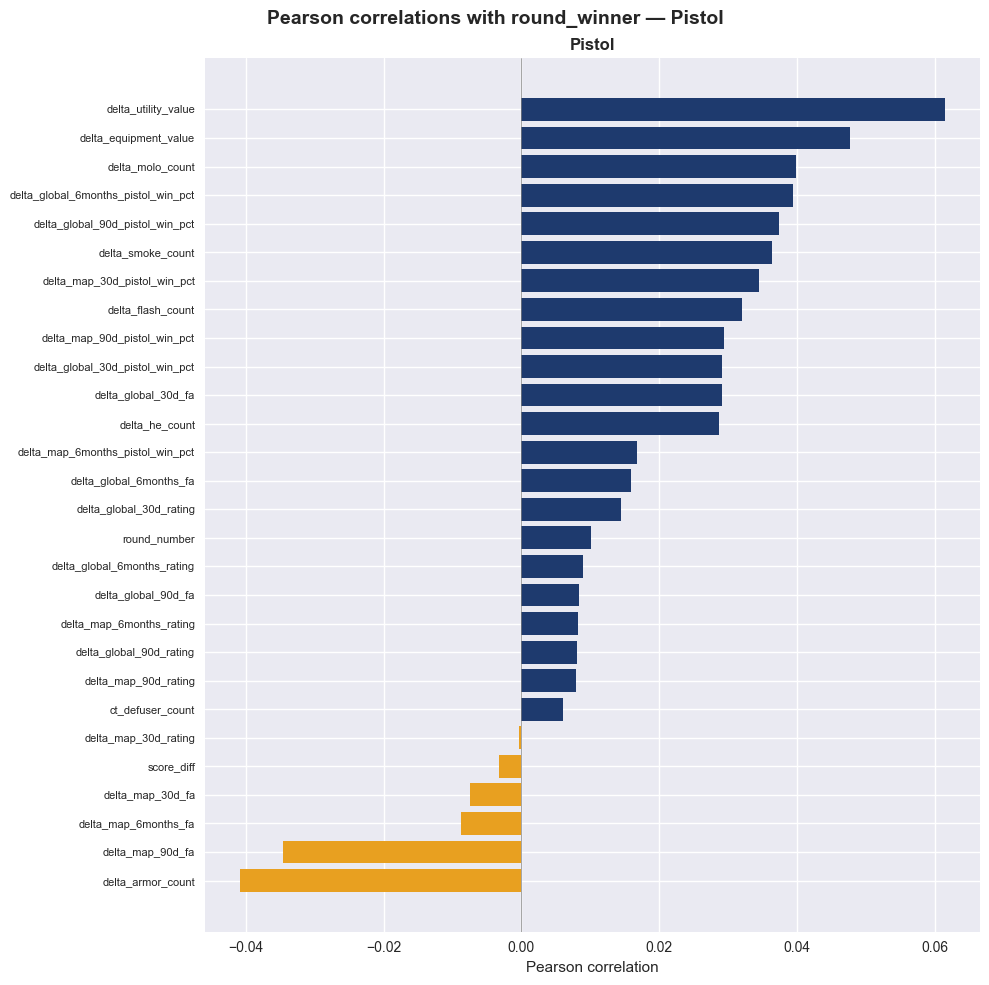

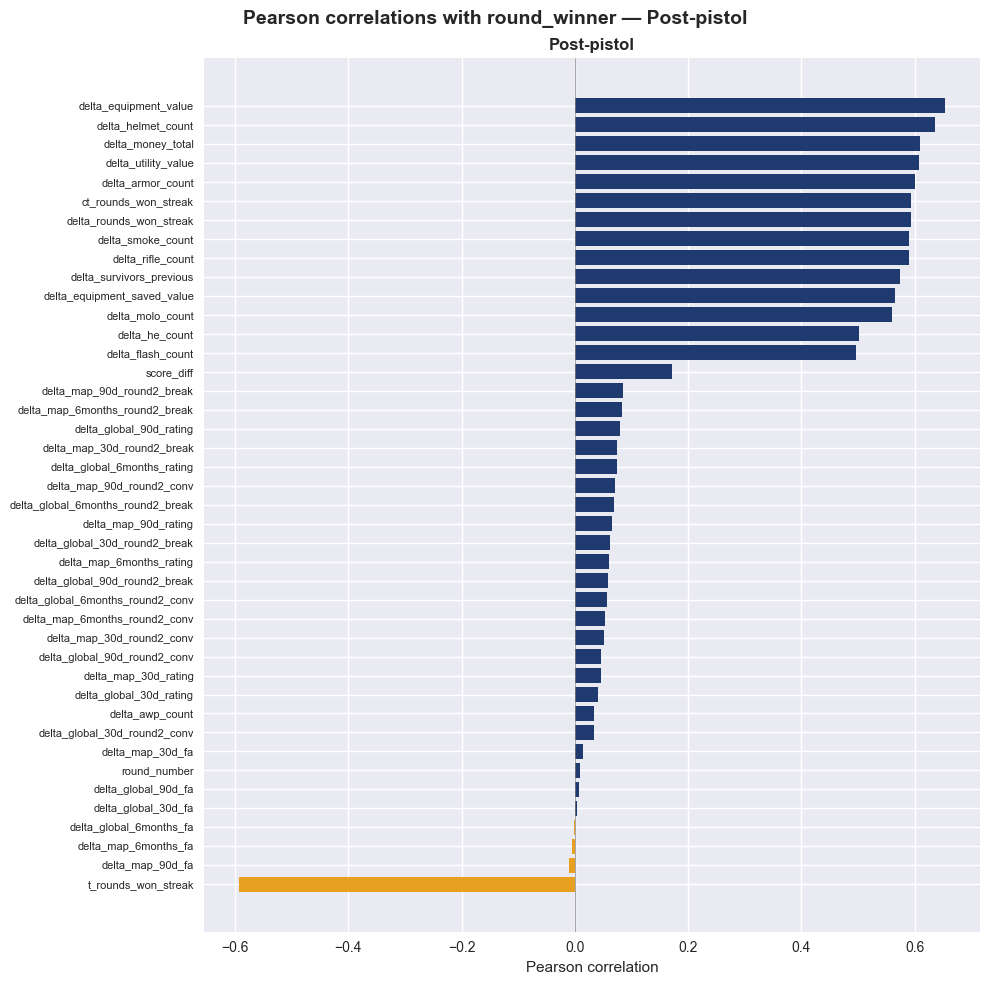

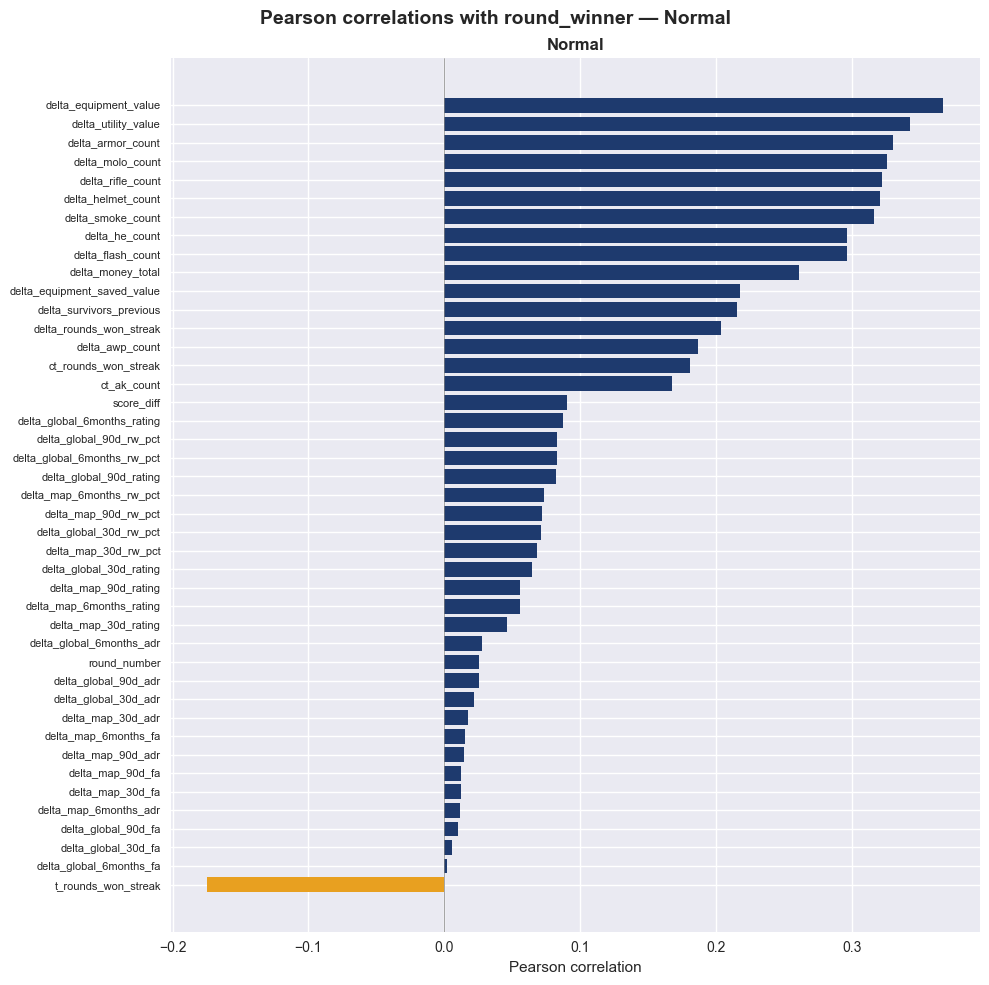

In [14]:
for df_delta, label, fname in [
    (df_pistol_delta,      "Pistol",       "dataset_correl_pistol"),
    (df_post_pistol_delta, "Post-pistol",  "dataset_correl_post_pistol"),
    (df_normal_delta,      "Normal",       "dataset_correl_normal"),
]:
    fig, ax = plt.subplots(figsize=(10, 10))
    plot_correl(df_delta, ax, label)
    plt.suptitle(f"Pearson correlations with round_winner — {label}",
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(f'../report/figures/{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## 2. Target distribution and motivation for the split

### 2.1 Win rate per round type

In [15]:
df_winrate = pd.DataFrame({
    'round_type': ['Pistol', 'Post-pistol', 'Normal'],
    'CT': [df_pistol['round_winner'].mean(), 
           df_post_pistol['round_winner'].mean(), 
           df_normal['round_winner'].mean()],
    'T':  [1 - df_pistol['round_winner'].mean(), 
           1 - df_post_pistol['round_winner'].mean(), 
           1 - df_normal['round_winner'].mean()]
})

df_long = df_winrate.melt(id_vars='round_type',
                          var_name = 'team',
                          value_name='win_pct')


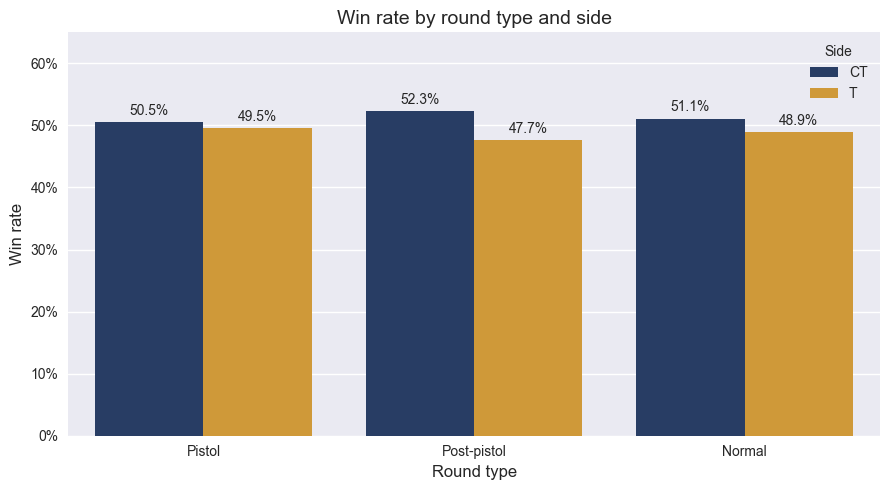

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=df_long, 
    x='round_type', 
    y='win_pct', 
    hue='team',
    palette={'CT': ct_color, 'T': t_color},
    errorbar=None,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, 
                 fmt=lambda x: f'{x*100:.1f}%',        
                 label_type='edge',   
                 padding=3,
                 fontsize=10)

ax.set_ylim(0, 0.65)                          
ax.set_xlabel('Round type', fontsize=12)
ax.set_ylabel('Win rate', fontsize=12)
ax.set_title('Win rate by round type and side', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Side')

plt.tight_layout()
fig.savefig('../report/figures/dataset_winrate_by_round_type.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 equipment_value CDF per round type


In [17]:
def Fdremp(valeurs, color, label, ax, alpha=1, linestyle='-'):
    valeurs = np.sort(valeurs)
    n = len(valeurs)
    y = np.arange(1, n+1) / n
    ax.plot(valeurs, y, c=color, label=label, linewidth=2, alpha=alpha, linestyle=linestyle)


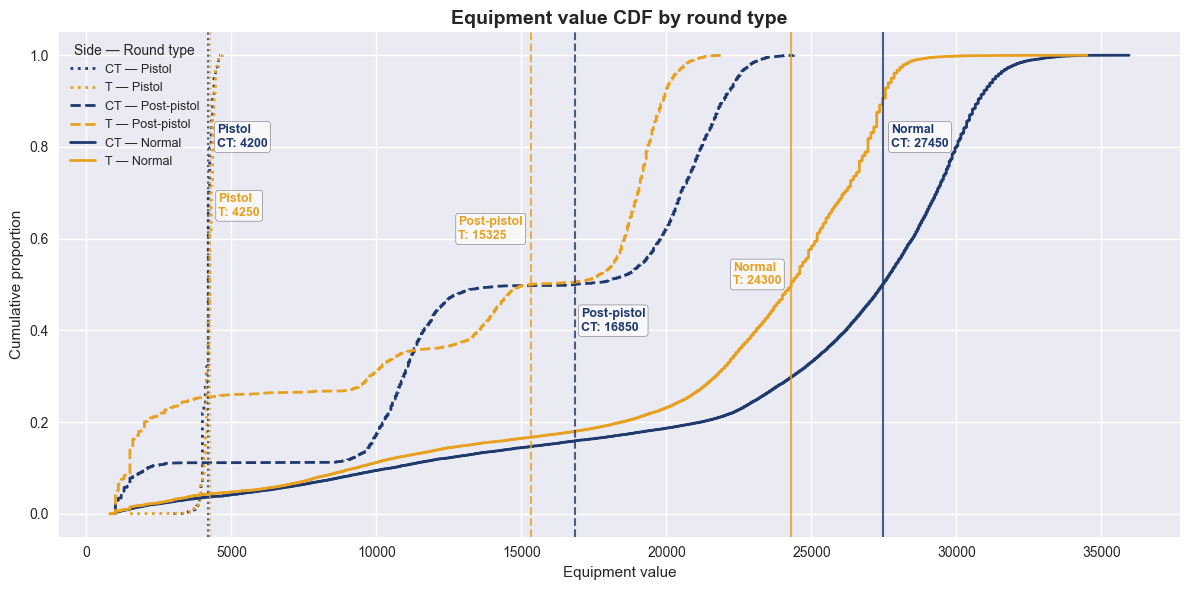

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

for df, ls, round_type in zip(dfs, 
                              linestyles, 
                              round_types):
    Fdremp(df['ct_equipment_value'], ct_color, f'CT — {round_type}', ax, linestyle=ls)
    Fdremp(df['t_equipment_value'], t_color, f'T — {round_type}', ax, linestyle=ls)

offsets = {
    'Pistol':      {'ct_x': 300,   'ct_y': 0.85, 't_x': 300,   't_y': 0.70},
    'Post-pistol': {'ct_x': 200,   'ct_y': 0.45, 't_x': -2500, 't_y': 0.65},
    'Normal':      {'ct_x': 300,   'ct_y': 0.85, 't_x': -2000, 't_y': 0.55},
}

for j, (df, ls, round_type) in enumerate(zip(dfs, linestyles, round_types)):
    ct_median = df['ct_equipment_value'].median()
    t_median  = df['t_equipment_value'].median()

    ax.axvline(ct_median, color=ct_color, linestyle=ls, linewidth=1.5, alpha=0.8)
    ax.axvline(t_median,  color=t_color,  linestyle=ls, linewidth=1.5, alpha=0.8)

    o = offsets[round_type]
    ax.text(ct_median + o['ct_x'], o['ct_y'], f'{round_type}\nCT: {ct_median:.0f}',
            color=ct_color, fontsize=9, va='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    ax.text(t_median + o['t_x'], o['t_y'], f'{round_type}\nT: {t_median:.0f}',
            color=t_color, fontsize=9, va='top', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Equipment value', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Equipment value CDF by round type', fontsize=14, fontweight='bold')
ax.legend(title='Side — Round type', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/dataset_equipment_cdf.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Pistol rounds (R1 and R13)

### 3.1 Pistol budget allocation


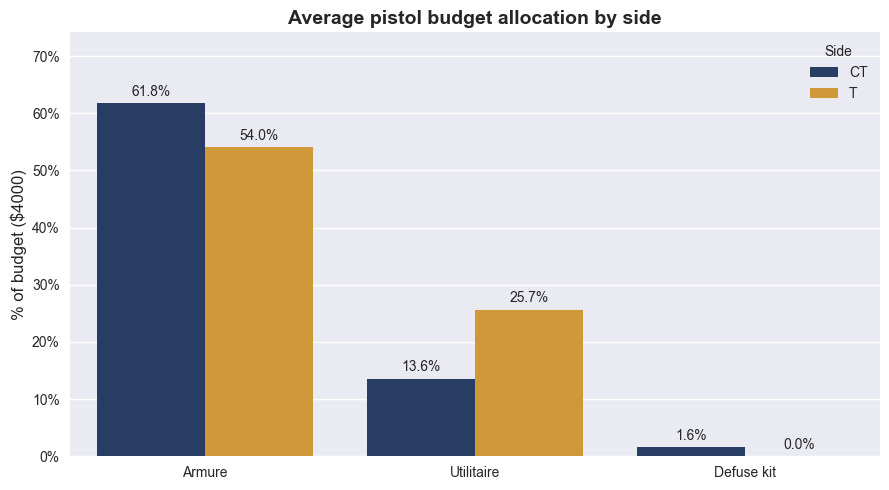

In [19]:
BUDGET = 4000

categories = {
    'Armure':      {'CT': (df_pistol['ct_armor_count']   * 650).mean(),
                    'T':  (df_pistol['t_armor_count']    * 650).mean()},
    'Utilitaire':  {'CT':  df_pistol['ct_utility_value'].mean(),
                    'T':   df_pistol['t_utility_value'].mean()},
    'Defuse kit':  {'CT': (df_pistol['ct_defuser_count'] * 400).mean(),
                    'T':  0.0},
}

df_budget = pd.DataFrame([
    {'Categorie': cat, 'Side': side, 'pct': val / BUDGET * 100}
    for cat, sides in categories.items()
    for side, val in sides.items()
])

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=df_budget,
    x='Categorie',
    y='pct',
    hue='Side',
    palette={'CT': ct_color, 'T': t_color},
    errorbar=None,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container,
                 fmt=lambda x: f'{x:.1f}%',
                 label_type='edge',
                 padding=3,
                 fontsize=10)

ax.set_ylim(0, df_budget['pct'].max() * 1.2)
ax.set_xlabel('')
ax.set_ylabel('% of budget ($4000)', fontsize=12)
ax.set_title('Average pistol budget allocation by side', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(title='Side')

plt.tight_layout()
fig.savefig('../report/figures/pistol_budget_allocation.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Utility

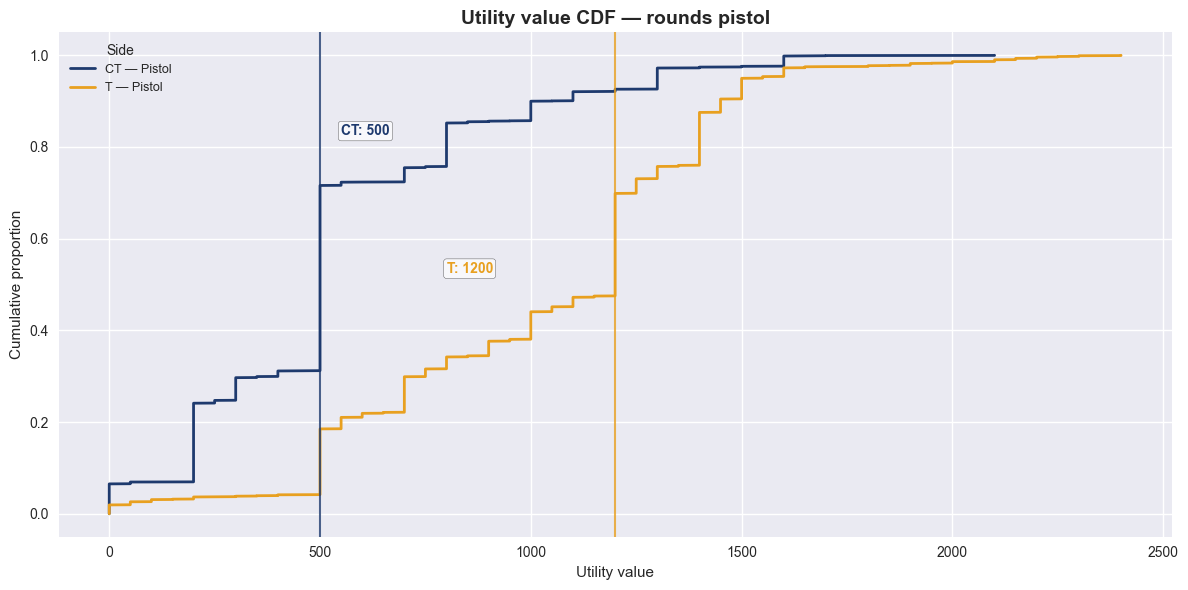

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

Fdremp(df_pistol['ct_utility_value'], ct_color, 'CT — Pistol', ax, linestyle='-')
Fdremp(df_pistol['t_utility_value'],  t_color,  'T — Pistol',  ax, linestyle='-')

ct_median = df_pistol['ct_utility_value'].median()
t_median  = df_pistol['t_utility_value'].median()

ax.axvline(ct_median, color=ct_color, linestyle='-', linewidth=1.5, alpha=0.8)
ax.axvline(t_median,  color=t_color,  linestyle='-', linewidth=1.5, alpha=0.8)

ax.text(ct_median + 50, 0.85, f'CT: {ct_median:.0f}',
        color=ct_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.text(t_median - 400, 0.55, f'T: {t_median:.0f}',
        color=t_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Utility value', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Utility value CDF — rounds pistol', fontsize=14, fontweight='bold')
ax.legend(title='Side', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/pistol_utility_cdf.png', dpi=150, bbox_inches='tight')
plt.show()


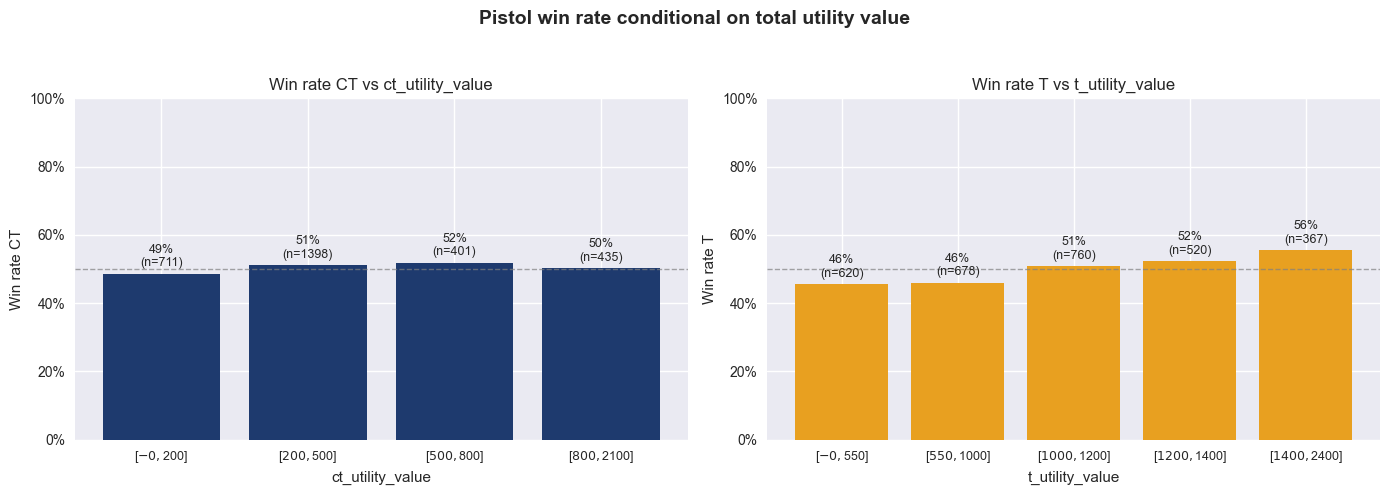

In [21]:
results = []
for side, col in [('CT', 'ct_utility_value'), ('T', 't_utility_value')]:
    agg = qcut_winrate(df_pistol, col, q=5)
    if side == 'T':
        agg['wr'] = 1 - agg['wr']
    results.append((side, col, agg))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (side, col, agg), color in zip(axes, results, [ct_color, t_color]):
    bars = ax.bar(range(len(agg)), agg['wr'], color=color)
    labels = [f'{v*100:.0f}%\n(n={n})' for v, n in zip(agg['wr'], agg['n'])]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([f'[${b.left:.0f}, ${b.right:.0f}]' for b in agg['bin']], fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_title(f'Win rate {side} vs {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel(f'Win rate {side}')

plt.suptitle("Pistol win rate conditional on total utility value",
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('../report/figures/pistol_utility_winrate.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Map effect

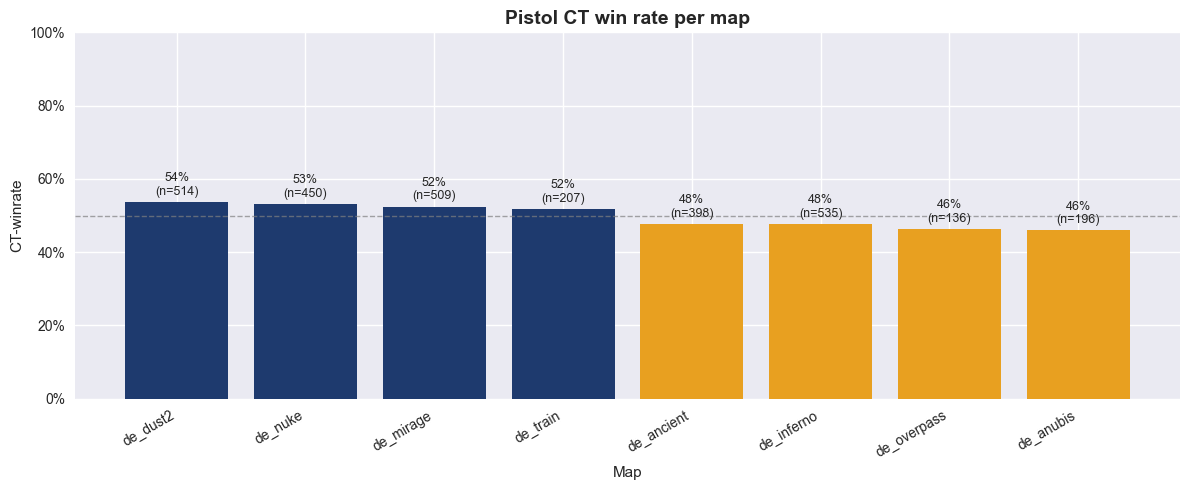

In [22]:
agg_map = (
    df_pistol
          .groupby('map_name')
          .agg(ct_winrate=('round_winner', 'mean'),
               n=('round_winner', 'size'))
          .reset_index()
          .sort_values('ct_winrate', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))

colors = [ct_color if v >= 0.5 else t_color for v in agg_map['ct_winrate']]
bars = ax.bar(agg_map['map_name'], agg_map['ct_winrate'], color=colors)

labels = [f'{v*100:.0f}%\n(n={n})'
          for v, n in zip(agg_map['ct_winrate'], agg_map['n'])]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_title("Pistol CT win rate per map",
             fontsize=14, fontweight='bold')
ax.set_xlabel('Map')
ax.set_ylabel('CT-winrate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

fig.savefig('../report/figures/pistol_map_winrate.png',
            dpi=150, bbox_inches='tight')


### 3.4 HLTV stats

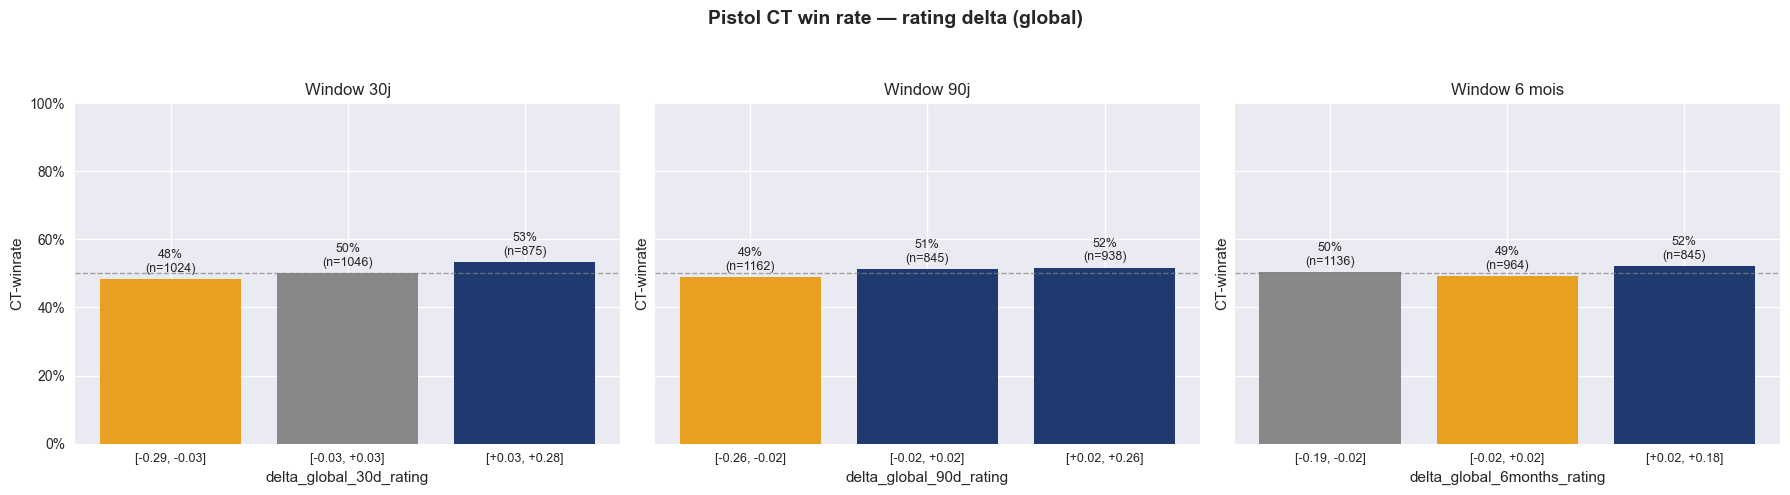

In [23]:
windows = ['30d', '90d', '6months']
windows_label = {'30d': '30j', '90d': '90j', '6months': '6 mois'}
features = [('global', 'rating')]

for scope, metric in features:
    aggs = []
    for window in windows:
        delta_col = f'delta_{scope}_{window}_{metric}'
        aggs.append((window, delta_col, qcut_winrate(df_pistol_delta, delta_col, q=3)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (window, delta_col, agg) in zip(axes, aggs):
        colors = [bar_color(v) for v in agg['wr']]
        bars = ax.bar(range(len(agg)), agg['wr'], color=colors)
        labels = [f'{v*100:.0f}%\n(n={n})' for v, n in zip(agg['wr'], agg['n'])]
        ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xticks(range(len(agg)))
        ax.set_xticklabels([f'[{b.left:+.2f}, {b.right:+.2f}]' for b in agg['bin']], fontsize=9)
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
        ax.set_title(f'Window {windows_label[window]}', fontsize=12)
        ax.set_xlabel(delta_col)
        ax.set_ylabel('CT-winrate')

    plt.suptitle(f'Pistol CT win rate — {metric} delta ({scope})', fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(f'../report/figures/pistol_hltv_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4. Post-pistol rounds (R2 and R14)

In [24]:
ct_won = df_post_pistol['ct_rounds_won_streak'] == 1
plant  = df_post_pistol['previous_bomb_planted'] == 1

cas1 = ct_won  & ~plant
cas2 = ct_won  &  plant
cas3 = ~ct_won &  plant
cas4 = ~ct_won & ~plant

def buy(v):
    if v < 5000:    return 'Eco'
    elif v < 17000: return 'Force'
    else:           return 'Full'

loser_equip = df_post_pistol['t_equipment_value'].where(ct_won, df_post_pistol['ct_equipment_value'])
loser_force = loser_equip.apply(buy) == 'Force'
loser_eco   = loser_equip.apply(buy) == 'Eco'

loser_won_pp = (
    (ct_won & (df_post_pistol['round_winner'] == 0)) |
    (~ct_won & (df_post_pistol['round_winner'] == 1))
).astype(int)


### 4.1 Win rate by pistol outcome

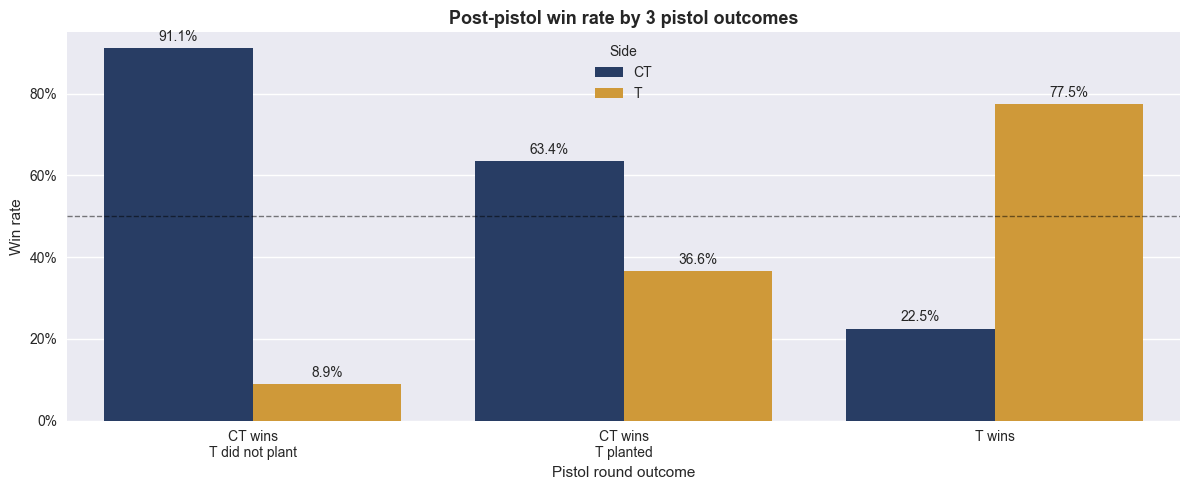

In [25]:
labels_3 = [
    "CT wins\nT did not plant",
    "CT wins\nT planted",
    "T wins"
]

df_3 = pd.DataFrame({
    'pistol_res': labels_3,
    'CT': [df_post_pistol.loc[cas1, 'round_winner'].mean(),
           df_post_pistol.loc[cas2, 'round_winner'].mean(),
           df_post_pistol.loc[cas3 | cas4, 'round_winner'].mean()],
    'T':  [1 - df_post_pistol.loc[cas1, 'round_winner'].mean(),
           1 - df_post_pistol.loc[cas2, 'round_winner'].mean(),
           1 - df_post_pistol.loc[cas3 | cas4, 'round_winner'].mean()],
})

df_long = pd.melt(df_3, id_vars='pistol_res', var_name='team', value_name='win_pct')
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_long, x='pistol_res', y='win_pct', hue='team',
            palette={'CT': ct_color, 'T': t_color}, errorbar=None, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{x*100:.1f}%', padding=3, fontsize=10)
ax.set_ylim(0, 0.95)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('Pistol round outcome', fontsize=11)
ax.set_ylabel('Win rate', fontsize=11)
ax.set_title('Post-pistol win rate by 3 pistol outcomes', fontsize=13, fontweight='bold')
ax.legend(title='Side')
plt.tight_layout()
fig.savefig('../report/figures/post_pistol_winrate_by_pistol_outcome_3_cases.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 money_total CDF

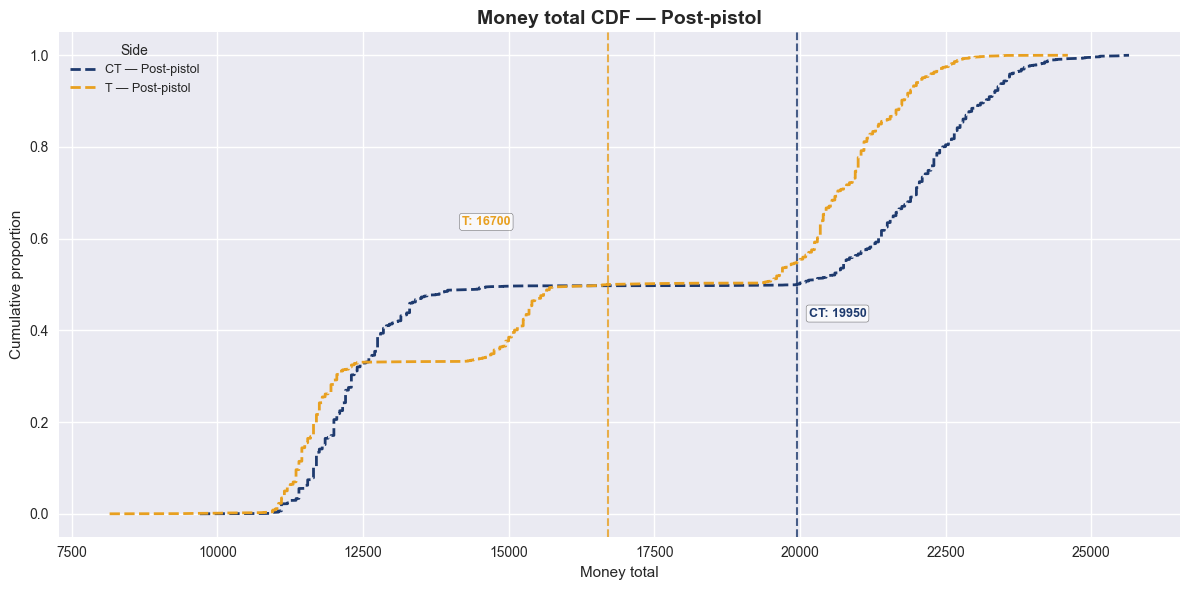

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

Fdremp(df_post_pistol['ct_money_total'], ct_color, 'CT — Post-pistol', ax, linestyle='--')
Fdremp(df_post_pistol['t_money_total'],  t_color,  'T — Post-pistol',  ax, linestyle='--')

ct_median = df_post_pistol['ct_money_total'].median()
t_median  = df_post_pistol['t_money_total'].median()

ax.axvline(ct_median, color=ct_color, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(t_median,  color=t_color,  linestyle='--', linewidth=1.5, alpha=0.8)

ax.text(ct_median + 200, 0.45, f'CT: {ct_median:.0f}',
        color=ct_color, fontsize=9, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.text(t_median - 2500, 0.65, f'T: {t_median:.0f}',
        color=t_color, fontsize=9, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Money total', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Money total CDF — Post-pistol', fontsize=14, fontweight='bold')
ax.legend(title='Side', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_money_cdf_global.png',
            dpi=150, bbox_inches='tight')
plt.show()


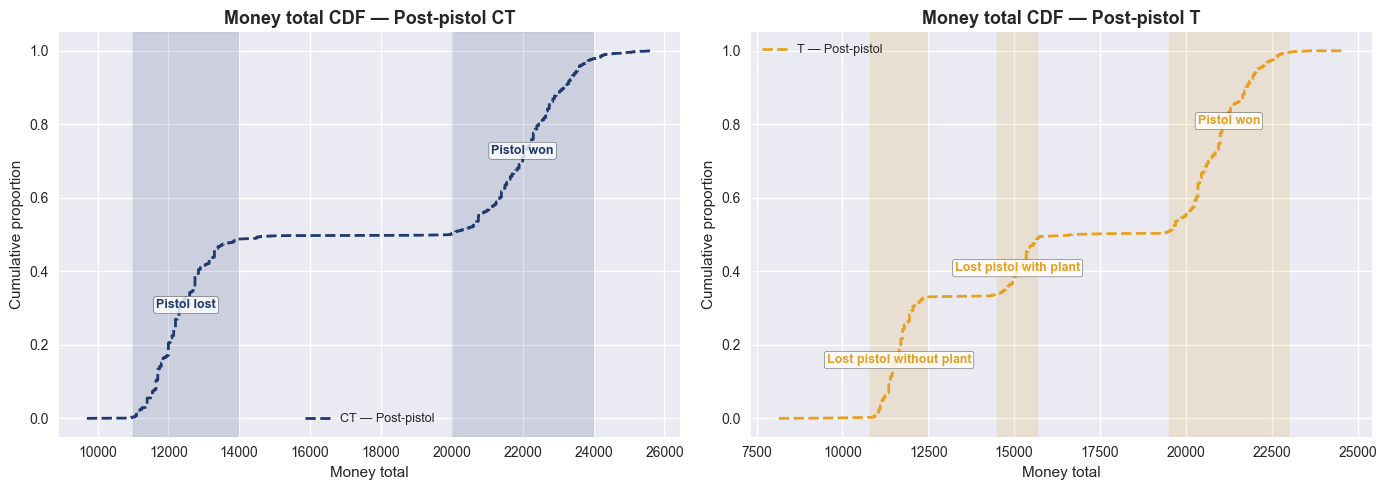

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sauts_ct = [
    (11000, 14000, 'Pistol lost',   0.30),
    (20000, 24000, 'Pistol won',    0.72),
]

sauts_t = [
    (10800,   12500,  'Lost pistol without plant',            0.15),
    (14500,  15700, 'Lost pistol with plant',  0.40),
    (19500, 23000, 'Pistol won',  0.80),
]

for ax, col, sauts, side in zip(
    axes,
    ['ct_money_total', 't_money_total'],
    [sauts_ct, sauts_t],
    ['CT', 'T']
):
    color = ct_color if side == 'CT' else t_color

    Fdremp(df_post_pistol[col], color, f'{side} — Post-pistol', ax, linestyle='--')

    for x1, x2, label, y_text in sauts:
        ax.axvspan(x1, x2, alpha=0.15, color=color)
        ax.text((x1 + x2) / 2, y_text, label,
                ha='center', fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    ax.set_title(f'Money total CDF — Post-pistol {side}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Money total', fontsize=11)
    ax.set_ylabel('Cumulative proportion', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_money_cdf.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Validation: `previous_bomb_planted`

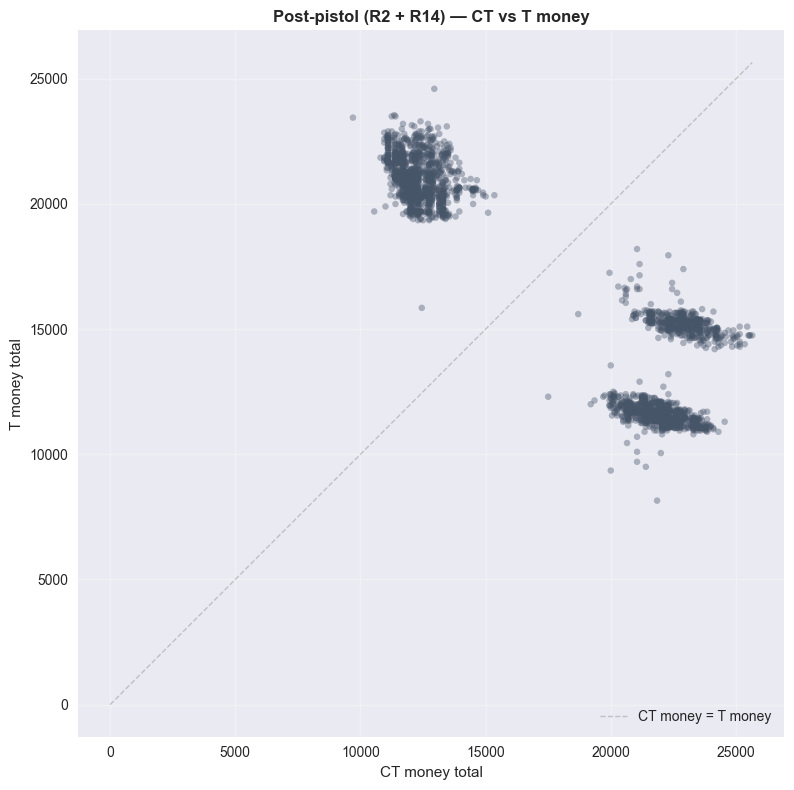

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df_post_pistol['ct_money_total'], df_post_pistol['t_money_total'],
           c='#475569', alpha=0.4, s=22, edgecolor='none')

lim_max = max(df_post_pistol['ct_money_total'].max(),
              df_post_pistol['t_money_total'].max())
ax.plot([0, lim_max], [0, lim_max],
        color='gray', linestyle='--', linewidth=1, alpha=0.4,
        label='CT money = T money')

ax.set_xlabel('CT money total')
ax.set_ylabel('T money total')
ax.set_title('Post-pistol (R2 + R14) — CT vs T money', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig('../report/figures/post_pistol_money_scatter_raw.png',
            dpi=150, bbox_inches='tight')
plt.show()


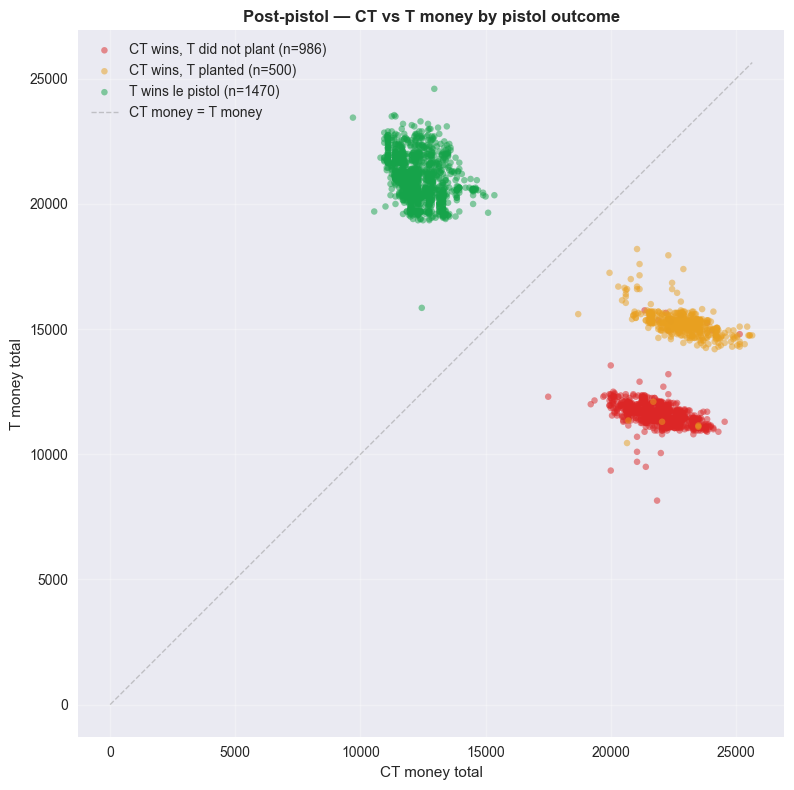

In [29]:
cases_scatter = [
    (cas1,         '#dc2626', "CT wins, T did not plant"),
    (cas2,         t_color,   "CT wins, T planted"),
    (cas3 | cas4,  '#16a34a', "T wins le pistol"),
]

fig, ax = plt.subplots(figsize=(10, 8))

for mask, color, label in cases_scatter:
    ax.scatter(df_post_pistol.loc[mask, 'ct_money_total'],
               df_post_pistol.loc[mask, 't_money_total'],
               c=color, label=f'{label} (n={mask.sum()})',
               alpha=0.5, s=22, edgecolor='none')

lim_max = max(df_post_pistol['ct_money_total'].max(),
              df_post_pistol['t_money_total'].max())
ax.plot([0, lim_max], [0, lim_max], color='gray', linestyle='--',
        linewidth=1, alpha=0.4, label='CT money = T money')

ax.set_xlabel('CT money total')
ax.set_ylabel('T money total')
ax.set_title('Post-pistol — CT vs T money by pistol outcome',
             fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_money_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 equipment_value CDF

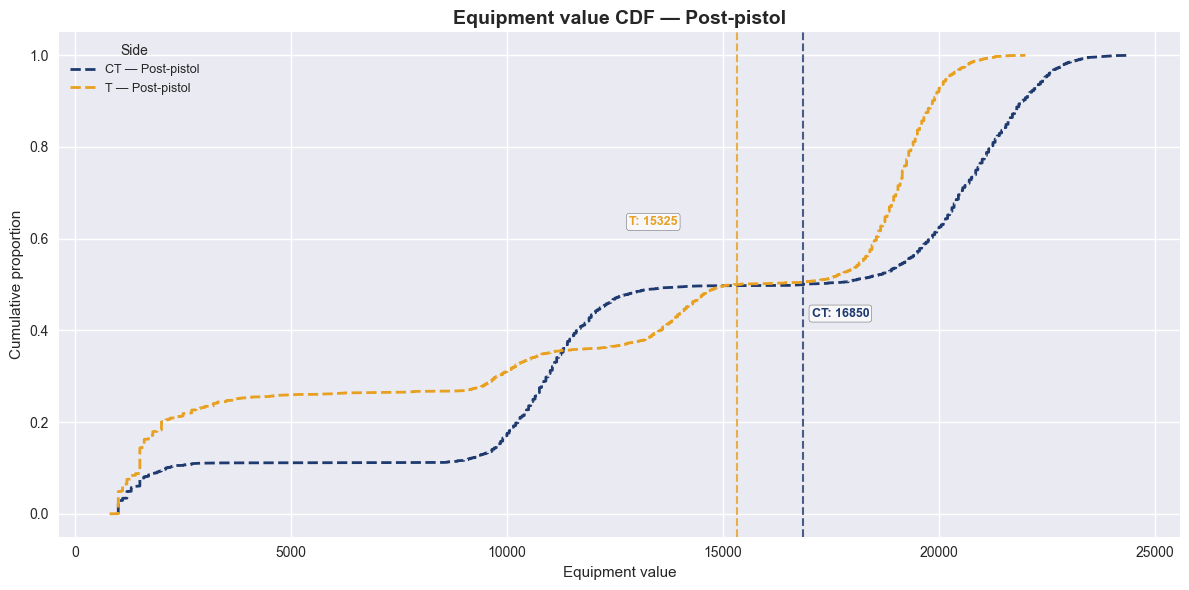

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

Fdremp(df_post_pistol['ct_equipment_value'], ct_color, 'CT — Post-pistol', ax, linestyle='--')
Fdremp(df_post_pistol['t_equipment_value'],  t_color,  'T — Post-pistol',  ax, linestyle='--')

ct_median = df_post_pistol['ct_equipment_value'].median()
t_median  = df_post_pistol['t_equipment_value'].median()

ax.axvline(ct_median, color=ct_color, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(t_median,  color=t_color,  linestyle='--', linewidth=1.5, alpha=0.8)

ax.text(ct_median + 200, 0.45, f'CT: {ct_median:.0f}',
        color=ct_color, fontsize=9, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.text(t_median - 2500, 0.65, f'T: {t_median:.0f}',
        color=t_color, fontsize=9, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Equipment value', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Equipment value CDF — Post-pistol', fontsize=14, fontweight='bold')
ax.legend(title='Side', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_equipment_cdf.png',
            dpi=150, bbox_inches='tight')
plt.show()


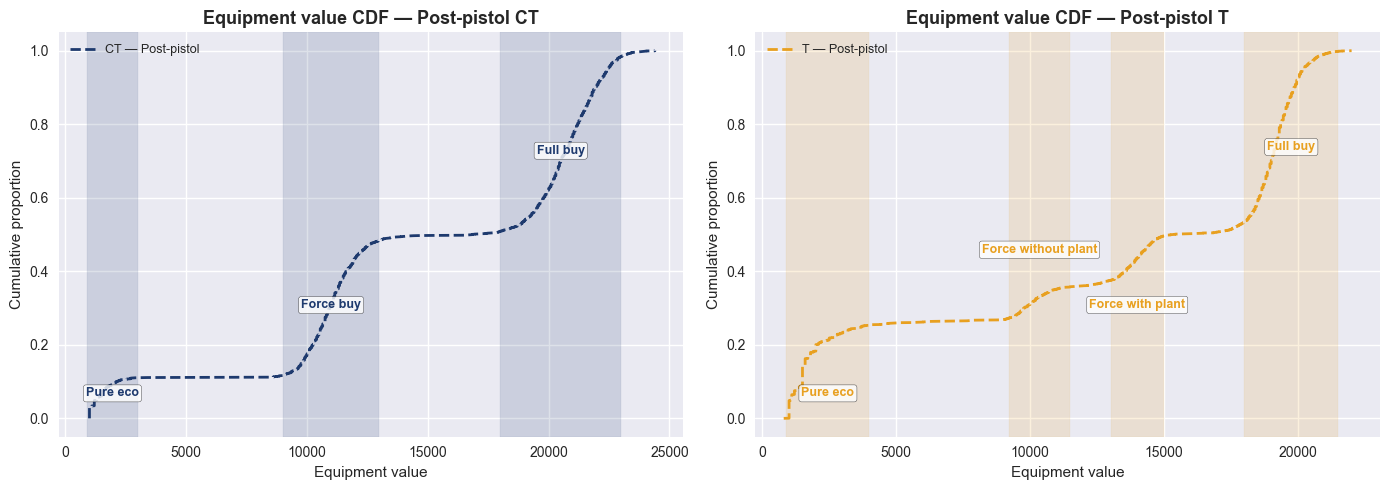

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sauts_ct = [
    (900,     3000,  'Pure eco',   0.06),
    (9000, 13000, 'Force buy',   0.30),
    (18000, 23000, 'Full buy',    0.72),
]

sauts_t = [
    (900,   4000,  'Pure eco',            0.06),
    (9200,  11500, 'Force without plant',  0.45),
    (13000, 15000, 'Force with plant',  0.30),
    (18000, 21500, 'Full buy',              0.73),
]

for ax, col, sauts, side in zip(
    axes,
    ['ct_equipment_value', 't_equipment_value'],
    [sauts_ct, sauts_t],
    ['CT', 'T']
):
    color = ct_color if side == 'CT' else t_color

    Fdremp(df_post_pistol[col], color, f'{side} — Post-pistol', ax, linestyle='--')

    for x1, x2, label, y_text in sauts:
        ax.axvspan(x1, x2, alpha=0.15, color=color)
        ax.text((x1 + x2) / 2, y_text, label,
                ha='center', fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    ax.set_title(f'Equipment value CDF — Post-pistol {side}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Equipment value', fontsize=11)
    ax.set_ylabel('Cumulative proportion', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_equipment_cdf_zones.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Buy decisions

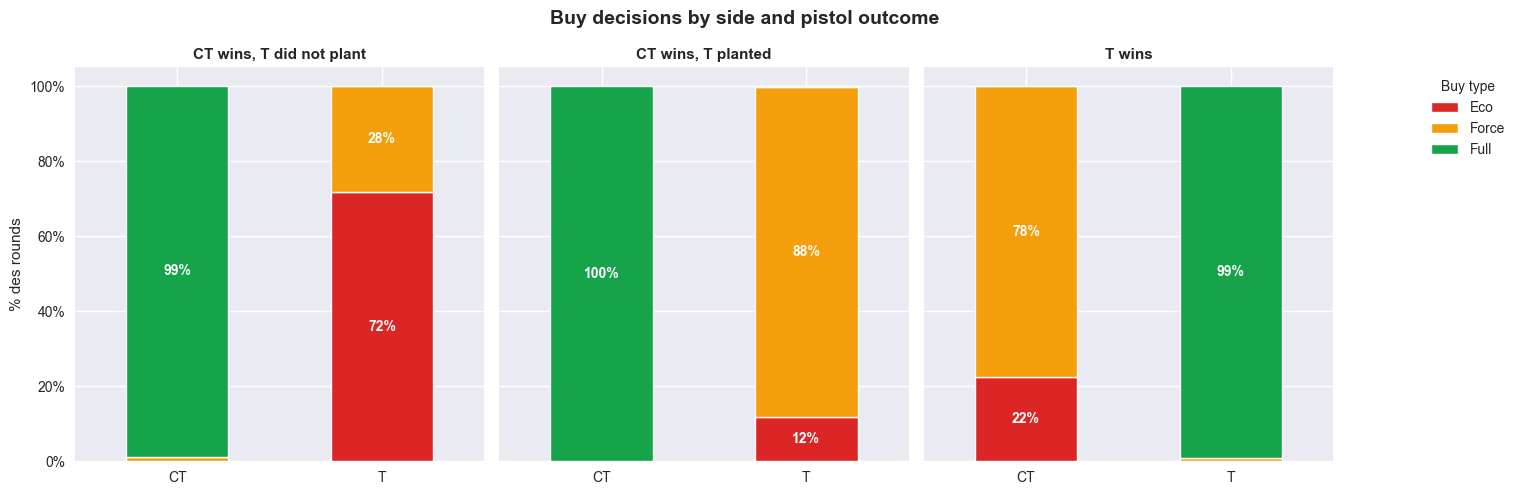

In [32]:
cases_buy = {
    "CT wins, T did not plant": cas1,
    "CT wins, T planted":        cas2,
    "T wins":                     cas3 | cas4,
}
buy_order  = ['Eco', 'Force', 'Full']
buy_colors = ['#dc2626', '#f59e0b', '#16a34a']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (label, mask) in zip(axes, cases_buy.items()):
    sub = df_post_pistol[mask]
    pct = pd.DataFrame({
        'CT': sub['ct_equipment_value'].apply(buy).value_counts(normalize=True),
        'T':  sub['t_equipment_value'].apply(buy).value_counts(normalize=True),
    }).T.reindex(columns=buy_order, fill_value=0)

    pct.plot(kind='bar', stacked=True, ax=ax, color=buy_colors,
             edgecolor='white', linewidth=1, legend=False)

    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{x*100:.0f}%' if x > 0.04 else '',
                     label_type='center', color='white',
                     fontweight='bold', fontsize=10)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

axes[0].set_ylabel('% des rounds')
axes[-1].legend(buy_order, loc='upper right',
                bbox_to_anchor=(1.45, 1.0), title='Buy type')

plt.suptitle('Buy decisions by side and pistol outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../report/figures/post_pistol_buy_decisions.png', dpi=150, bbox_inches='tight')
plt.show()


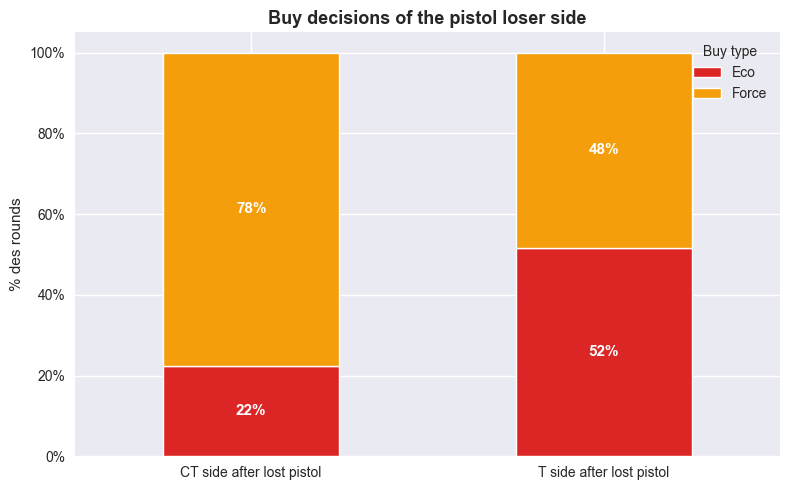

In [33]:
buy_type = loser_equip.apply(buy)

pct = pd.DataFrame({
    'CT side after lost pistol': buy_type[~ct_won].value_counts(normalize=True),
    'T side after lost pistol':  buy_type[ct_won].value_counts(normalize=True),
}).T[['Eco', 'Force']]

fig, ax = plt.subplots(figsize=(8, 5))
pct.plot(kind='bar', stacked=True, ax=ax, color=['#dc2626', '#f59e0b'],
         edgecolor='white', linewidth=1)

for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{x*100:.0f}%' if x > 0.04 else '',
                 label_type='center', color='white',
                 fontweight='bold', fontsize=11)

ax.set_xlabel('')
ax.set_ylabel('% des rounds')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('Buy decisions of the pistol loser side', fontsize=13, fontweight='bold')
ax.legend(title='Buy type', loc='upper right')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_loser_buy.png', dpi=150, bbox_inches='tight')
plt.show()


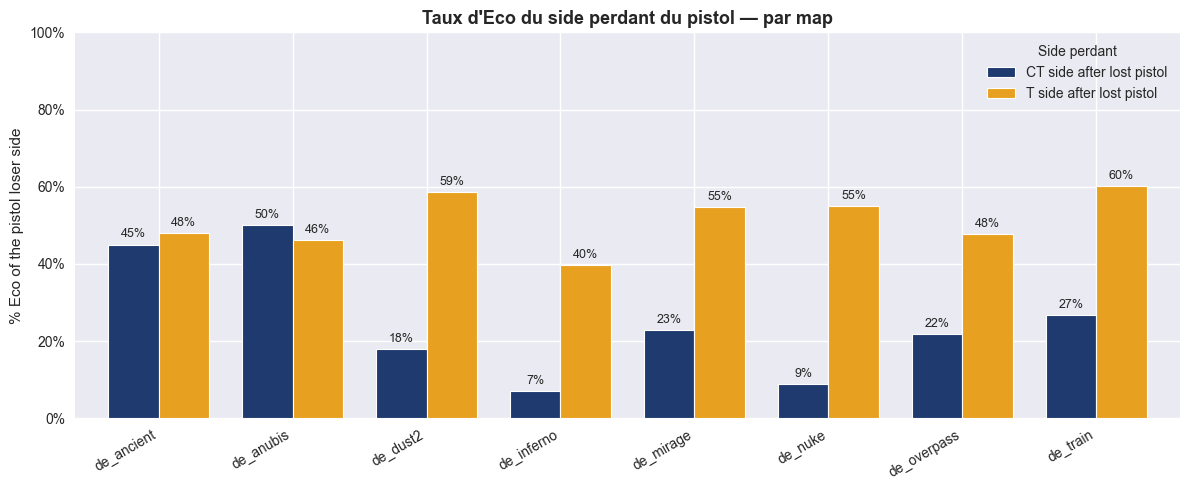

In [34]:
df_eco = pd.DataFrame({
    'map':  df_post_pistol['map_name'], 
    'side': np.where(ct_won, 'T side after lost pistol', 'CT side after lost pistol'),
    'eco':  loser_eco,
})

eco_pct = (df_eco.groupby(['map', 'side'])['eco'] 
                  .mean()
                  .unstack('side')
                  [['CT side after lost pistol', 'T side after lost pistol']])

fig, ax = plt.subplots(figsize=(12, 5))
eco_pct.plot(kind='bar', ax=ax, color=[ct_color, t_color],
             edgecolor='white', linewidth=0.8, width=0.75)

for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{x*100:.0f}%', padding=3, fontsize=9)

ax.set_ylabel("% Eco of the pistol loser side")
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.set_title("Taux d'Eco du side perdant du pistol — par map", fontsize=13, fontweight='bold')
ax.legend(title='Side perdant', loc='upper right')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_loser_eco_by_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.6 Loser's force-buy win rate

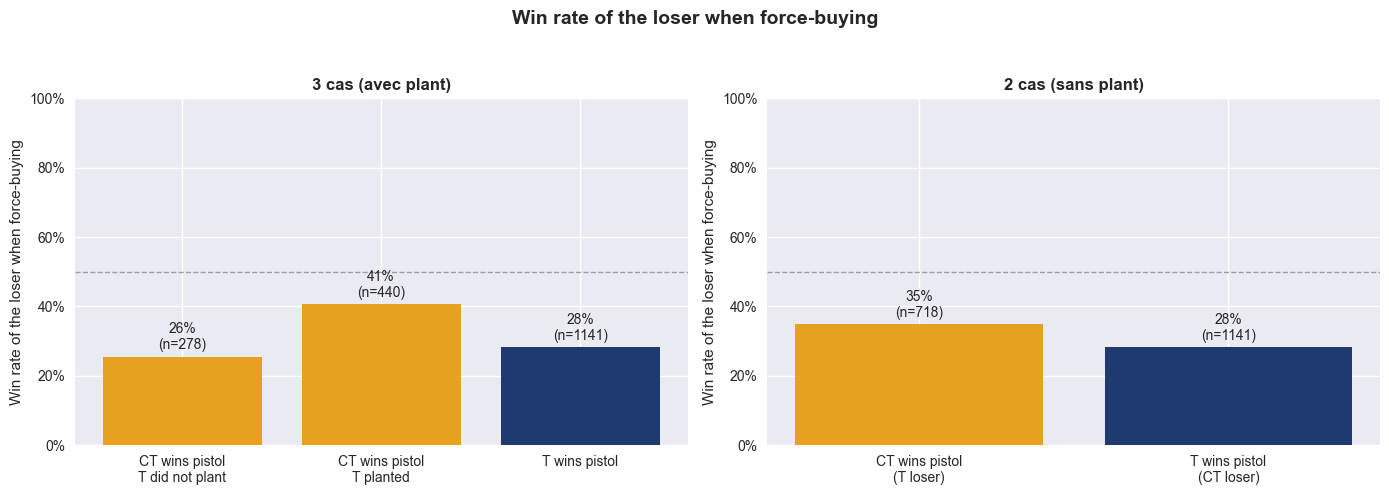

In [35]:
cases_3 = [
    ("CT wins pistol\nT did not plant", cas1,         t_color),
    ("CT wins pistol\nT planted",        cas2,         t_color),
    ("T wins pistol",                     cas3 | cas4,  ct_color),
]
df_3 = pd.DataFrame([
    {'cas': label,
     'wr':  loser_won_pp[m & loser_force].mean(),
     'n':   (m & loser_force).sum(),
     'color': c}
    for label, m, c in cases_3
])

cases_2 = [
    ("CT wins pistol\n(T loser)", ct_won,  t_color),
    ("T wins pistol\n(CT loser)", ~ct_won, ct_color),
]
df_2 = pd.DataFrame([
    {'cas': label,
     'wr':  loser_won_pp[m & loser_force].mean(),
     'n':   (m & loser_force).sum(),
     'color': c}
    for label, m, c in cases_2
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], df_3, "3 cas (avec plant)"),
                       (axes[1], df_2, "2 cas (sans plant)")]:
    bars = ax.bar(range(len(df)), df['wr'], color=df['color'].tolist())
    ax.bar_label(bars, labels=[f"{w*100:.0f}%\n(n={n})" for w, n in zip(df['wr'], df['n'])],
                 padding=3, fontsize=10)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['cas'], fontsize=10)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_ylabel('Win rate of the loser when force-buying')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Win rate of the loser when force-buying',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('../report/figures/post_pistol_force_wr_by_case.png', dpi=150, bbox_inches='tight')
plt.show()


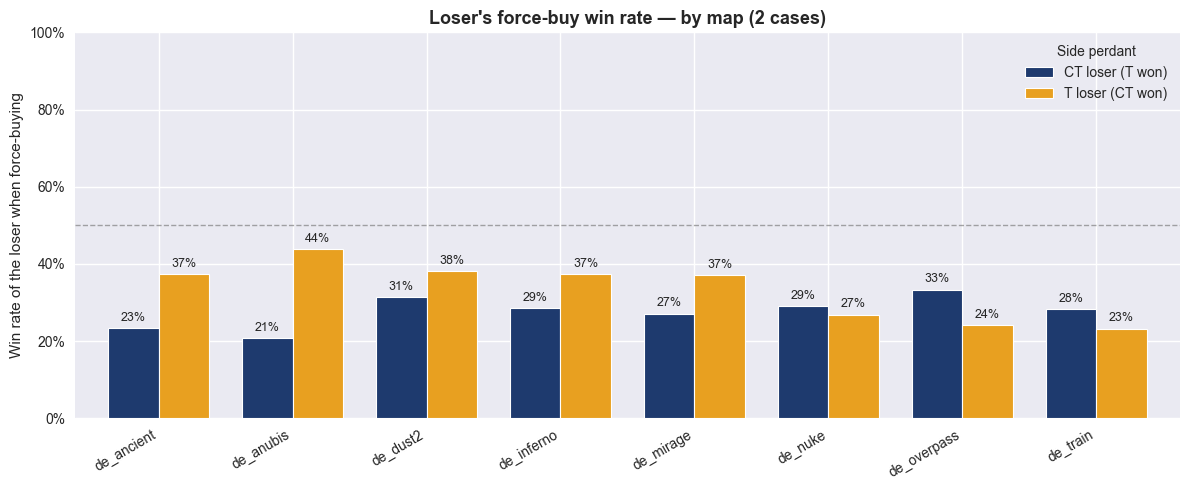

In [36]:
df_force = pd.DataFrame({
    'map':       df_post_pistol['map_name'],
    'loser':     np.where(ct_won, 'T loser (CT won)', 'CT loser (T won)'),
    'loser_won': loser_won_pp,
})[loser_force]

wr_by_map = (df_force.groupby(['map', 'loser'])['loser_won']
                     .mean()
                     .unstack('loser')
                     [['CT loser (T won)', 'T loser (CT won)']])

fig, ax = plt.subplots(figsize=(12, 5))
wr_by_map.plot(kind='bar', ax=ax, color=[ct_color, t_color],
               edgecolor='white', linewidth=0.8, width=0.75)

for c in ax.containers:
    ax.bar_label(c, fmt=lambda x: f'{x*100:.0f}%' if pd.notna(x) else '',
                 padding=3, fontsize=9)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_xlabel('')
ax.set_ylabel('Win rate of the loser when force-buying')
ax.set_title("Loser's force-buy win rate — by map (2 cases)",
             fontsize=13, fontweight='bold')
ax.legend(title='Side perdant', loc='upper right')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig('../report/figures/post_pistol_force_wr_by_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Normal rounds

### 5.1 CDF — equipment_value and money_total

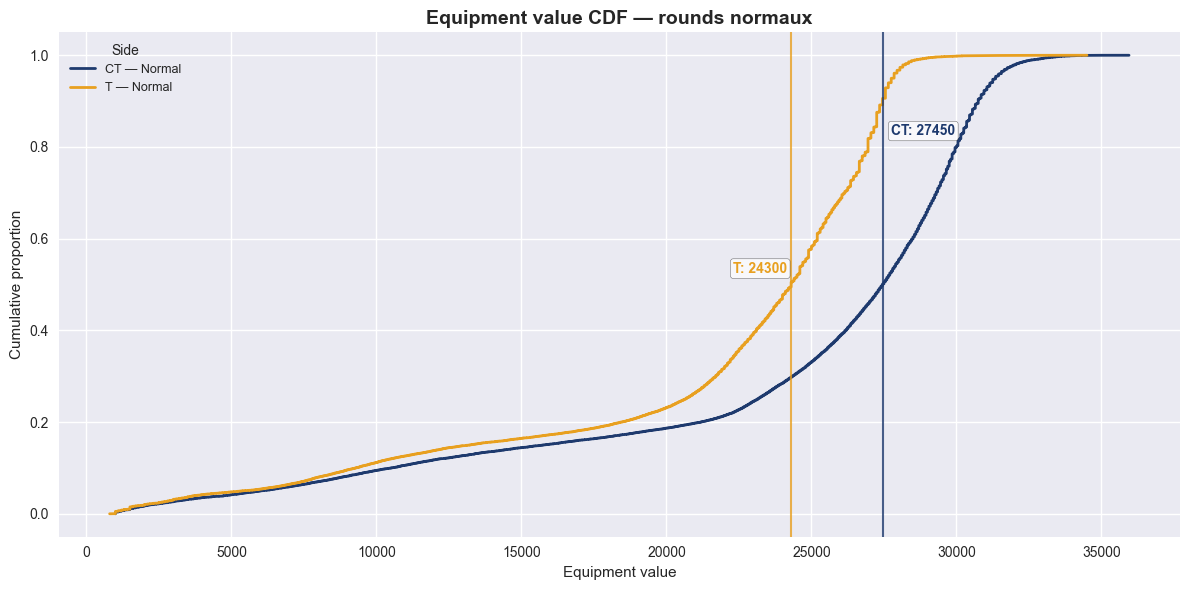

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

Fdremp(df_normal['ct_equipment_value'], ct_color, 'CT — Normal', ax, linestyle='-')
Fdremp(df_normal['t_equipment_value'],  t_color,  'T — Normal',  ax, linestyle='-')

ct_median = df_normal['ct_equipment_value'].median()
t_median  = df_normal['t_equipment_value'].median()

ax.axvline(ct_median, color=ct_color, linestyle='-', linewidth=1.5, alpha=0.8)
ax.axvline(t_median,  color=t_color,  linestyle='-', linewidth=1.5, alpha=0.8)

ax.text(ct_median + 300, 0.85, f'CT: {ct_median:.0f}',
        color=ct_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.text(t_median - 2000, 0.55, f'T: {t_median:.0f}',
        color=t_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Equipment value', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Equipment value CDF — rounds normaux', fontsize=14, fontweight='bold')
ax.legend(title='Side', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/normal_equipment_cdf.png', dpi=150, bbox_inches='tight')
plt.show()


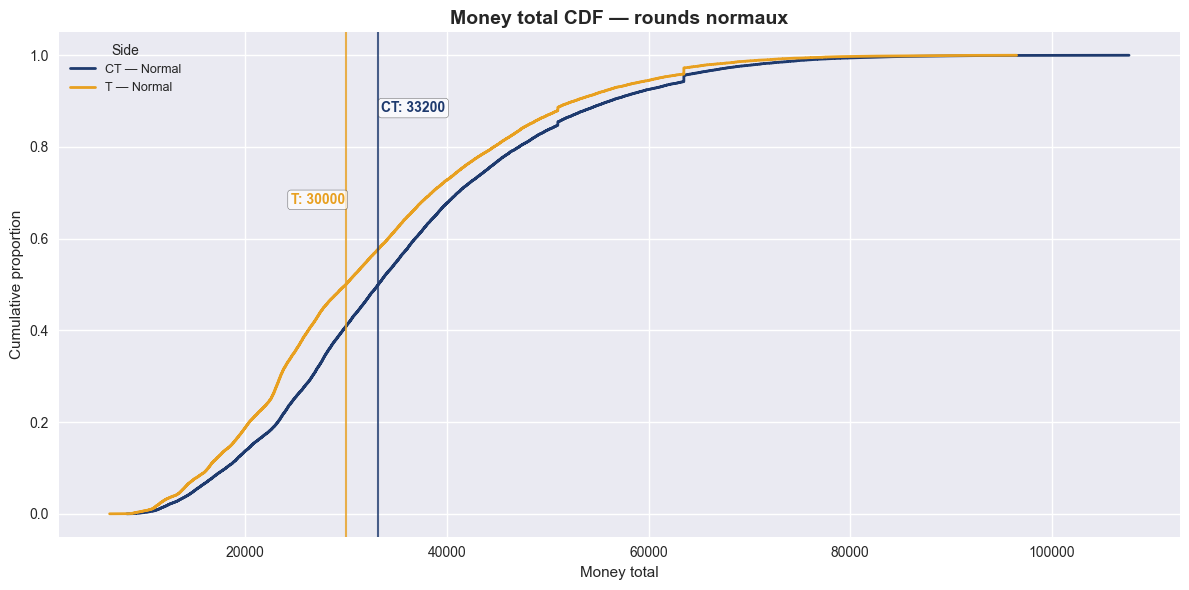

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

Fdremp(df_normal['ct_money_total'], ct_color, 'CT — Normal', ax, linestyle='-')
Fdremp(df_normal['t_money_total'],  t_color,  'T — Normal',  ax, linestyle='-')

ct_median = df_normal['ct_money_total'].median()
t_median  = df_normal['t_money_total'].median()

ax.axvline(ct_median, color=ct_color, linestyle='-', linewidth=1.5, alpha=0.8)
ax.axvline(t_median,  color=t_color,  linestyle='-', linewidth=1.5, alpha=0.8)

ax.text(ct_median + 300, 0.90, f'CT: {ct_median:.0f}',
        color=ct_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
ax.text(t_median - 5500, 0.70, f'T: {t_median:.0f}',
        color=t_color, fontsize=10, va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Money total', fontsize=11)
ax.set_ylabel('Cumulative proportion', fontsize=11)
ax.set_title('Money total CDF — rounds normaux', fontsize=14, fontweight='bold')
ax.legend(title='Side', fontsize=9)

plt.tight_layout()
fig.savefig('../report/figures/normal_money_total_cdf.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Predictive power of economic deltas

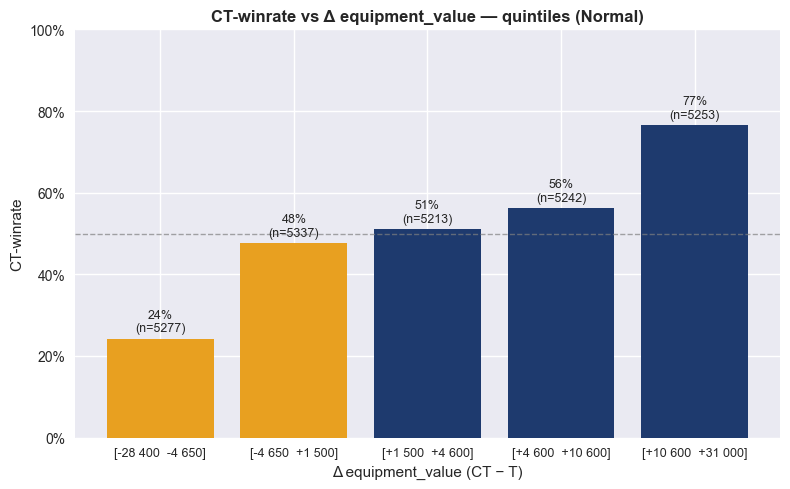

In [39]:

col, xlabel = 'delta_equipment_value', 'Δ equipment_value (CT − T)'
agg = qcut_winrate(df_normal_delta, col, q=5)

fig, ax = plt.subplots(figsize=(8, 5))

colors = [bar_color(v) for v in agg['wr']]
bars = ax.bar(range(len(agg)), agg['wr'], color=colors)
labels = [f'{v*100:.0f}%\n(n={n})' for v, n in zip(agg['wr'], agg['n'])]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(range(len(agg)))
ax.set_xticklabels([f'[{b.left:+,.0f}, {b.right:+,.0f}]'.replace(',', ' ')
                    for b in agg['bin']], fontsize=9)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_xlabel(xlabel)
ax.set_ylabel('CT-winrate')
ax.set_title('CT-winrate vs Δ equipment_value — quintiles (Normal)',
             fontsize=12, fontweight='bold')

fig.tight_layout()
fig.savefig('../report/figures/normal_delta_eco_winrate.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 5.3 AWP impact at equal economy

Full-buy rounds on both sides: 15478 / 26322 (58.8%)


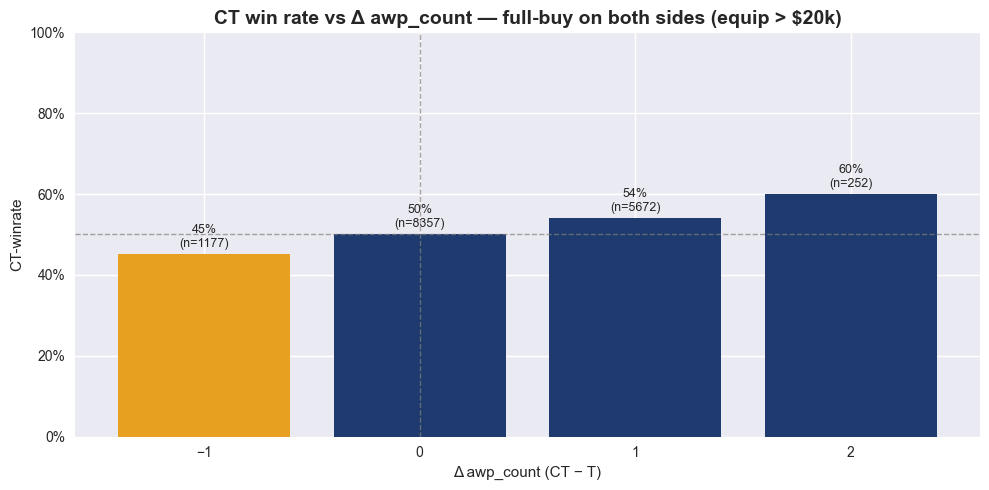

In [40]:
mask = (df_normal['ct_equipment_value'] > 20000) & (df_normal['t_equipment_value'] > 20000)
df_full = df_normal[mask].copy()
df_full['delta_awp_count'] = df_full['ct_awp_count'] - df_full['t_awp_count']

print(f"Full-buy rounds on both sides: {len(df_full)} / {len(df_normal)} "
      f"({len(df_full)/len(df_normal)*100:.1f}%)")

agg = (
    df_full.groupby('delta_awp_count')
      .agg(ct_winrate=('round_winner', 'mean'),
           n=('round_winner', 'size'))
      .reset_index()
)
agg = agg[agg['n'] >= 20]

fig, ax = plt.subplots(figsize=(10, 5))

colors = [ct_color if v >= 0.5 else t_color for v in agg['ct_winrate']]
bars = ax.bar(agg['delta_awp_count'], agg['ct_winrate'], color=colors)

labels = [f'{v*100:.0f}%\n(n={n})'
          for v, n in zip(agg['ct_winrate'], agg['n'])]
ax.bar_label(bars, labels=labels, padding=3, fontsize=9)

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0,   color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks([-1, 0, 1, 2])
ax.set_xlim(-1.6, 2.6)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.set_xlabel('Δ awp_count (CT − T)', fontsize=11)
ax.set_ylabel('CT-winrate', fontsize=11)
ax.set_title('CT win rate vs Δ awp_count — full-buy on both sides (equip > $20k)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
fig.savefig('../report/figures/normal_awp_full_buy.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 5.4 HLTV stats

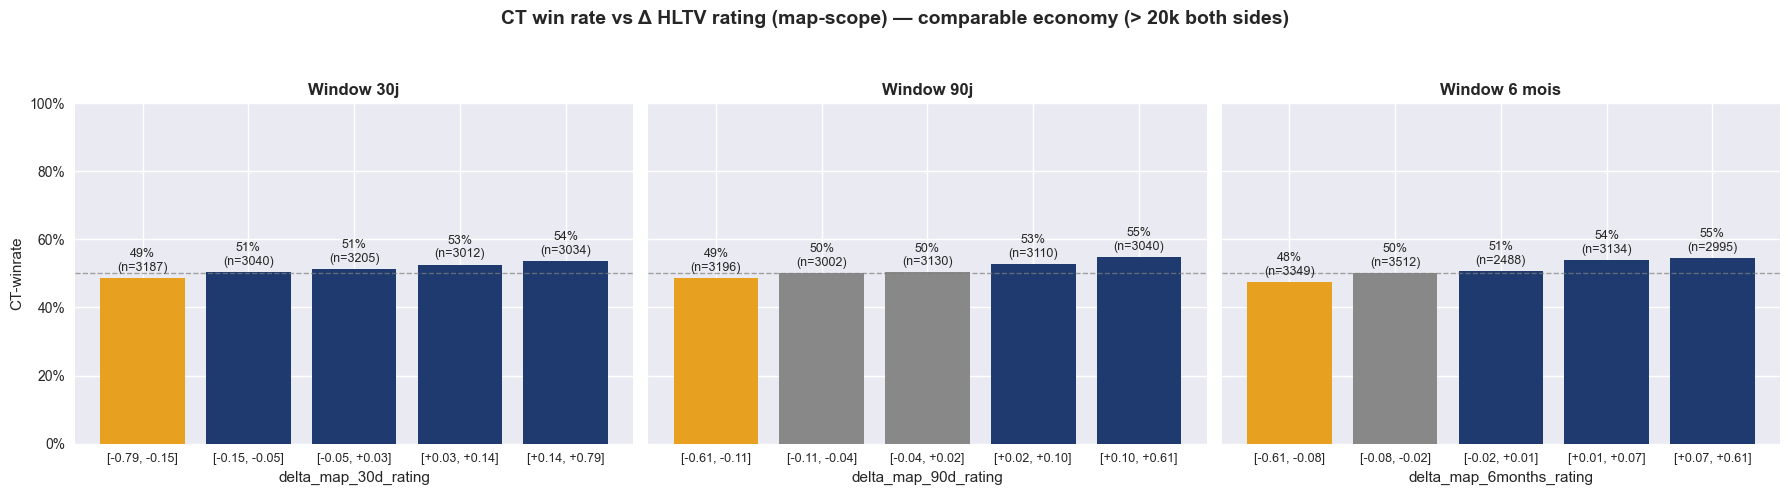

In [41]:
windows = ['30d', '90d', '6months']
windows_label = {'30d': '30j', '90d': '90j', '6months': '6 mois'}

high_eco = (df_normal['ct_equipment_value'] > 20000) & (df_normal['t_equipment_value'] > 20000)
df_filtered = df_normal_delta.loc[high_eco].copy()

aggs = []
for window in windows:
    delta_col = f'delta_map_{window}_rating'
    aggs.append((window, delta_col, qcut_winrate(df_filtered, delta_col, q=5)))

fig, axes = plt.subplots(1, len(windows), figsize=(18, 5), sharey=True)

for ax, (window, delta_col, agg) in zip(axes, aggs):
    colors = [bar_color(v) for v in agg['wr']]
    bars = ax.bar(range(len(agg)), agg['wr'], color=colors)
    labels = [f'{v*100:.0f}%\n(n={n})' for v, n in zip(agg['wr'], agg['n'])]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([f'[{b.left:+.2f}, {b.right:+.2f}]' for b in agg['bin']], fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_title(f'Window {windows_label[window]}', fontsize=12, fontweight='bold')
    ax.set_xlabel(delta_col)
    ax.set_ylabel('CT-winrate' if ax is axes[0] else '')

plt.suptitle('CT win rate vs Δ HLTV rating (map-scope) — comparable economy (> 20k both sides)',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig('../report/figures/normal_hltv_rating_qbins_high_eco.png',
            dpi=150, bbox_inches='tight')
plt.show()
